## Load all necessary Libraries 


In [1]:
# Import necessary libraries

# Basic libraries for numerical operations, data manipulation, and visualization
import numpy as np  # For numerical computations
import pandas as pd  # For data manipulation and analysis
import seaborn as sns  # For statistical data visualization
import matplotlib.pyplot as plt  # For creating plots and figures
import warnings  # To handle warnings in the code
warnings.filterwarnings('ignore')  # Ignore warnings to reduce clutter

# Data Preprocessing and Feature Scaling
from sklearn.preprocessing import StandardScaler, MinMaxScaler  # For feature scaling (Standard and Min-Max scaling)

# Data Splitting and Model Evaluation
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, RandomizedSearchCV,cross_validate  # For splitting data, cross-validation, and hyperparameter tuning
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix  # For model evaluation and performance metrics

# Handling Imbalanced Datasets
from imblearn.over_sampling import SMOTE  # For handling imbalanced datasets

# Machine Learning Models (for classification)
from sklearn.linear_model import LogisticRegression  # Logistic Regression for binary classification
from sklearn.neural_network import MLPClassifier  # Multi-layer Perceptron (Neural Network) for classification
from sklearn.svm import SVC  # Support Vector Machine classifier
from sklearn.ensemble import (
    RandomForestClassifier,  # Random Forest classifier
    GradientBoostingClassifier,  # Gradient Boosting classifier
    AdaBoostClassifier,  # AdaBoost classifier
    ExtraTreesClassifier,
    StackingClassifier,  # Stacking classifier
    VotingClassifier  # Voting classifier
)
from xgboost import XGBClassifier  # XGBoost classifier

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Input, Dropout
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.regularizers import l2
from sklearn.metrics import accuracy_score, classification_report

# Model Interpretability (SHAP)
import shap

In [2]:
df = pd.read_csv('fully_cleaned_heart_attack_data.csv')

In [3]:
df.columns

Index(['Sex', 'GeneralHealth', 'PhysicalHealthDays', 'MentalHealthDays',
       'LastCheckupTime', 'PhysicalActivities', 'SleepHours', 'HadHeartAttack',
       'HadAngina', 'HadStroke', 'HadAsthma', 'HadSkinCancer', 'HadCOPD',
       'HadDepressiveDisorder', 'HadKidneyDisease', 'HadArthritis',
       'HadDiabetes', 'DeafOrHardOfHearing', 'BlindOrVisionDifficulty',
       'DifficultyConcentrating', 'DifficultyWalking',
       'DifficultyDressingBathing', 'DifficultyErrands', 'SmokerStatus',
       'ChestScan', 'AgeCategory', 'BMI', 'AlcoholDrinkers', 'HIVTesting',
       'FluVaxLast12', 'PneumoVaxEver', 'TetanusLast10Tdap',
       'HighRiskLastYear', 'CovidPos', 'SystolicBP', 'DiastolicBP',
       'Cholesterol', 'PrematureFamilyHistory'],
      dtype='object')

In [4]:
# Let us first distingush datasets into num and object
num = []
cat = []
for i,col in enumerate(df.columns):
    if df[col].nunique() > 5:
        num.append(col)
    else:
        cat.append(col)
        df[col] = df[col].astype('object')

In [5]:
cat = df[cat]

In [6]:
num = df[num]

In [7]:
cat_f = df.select_dtypes('object').drop('HadHeartAttack',axis = 1)
num_f = df.select_dtypes('number')

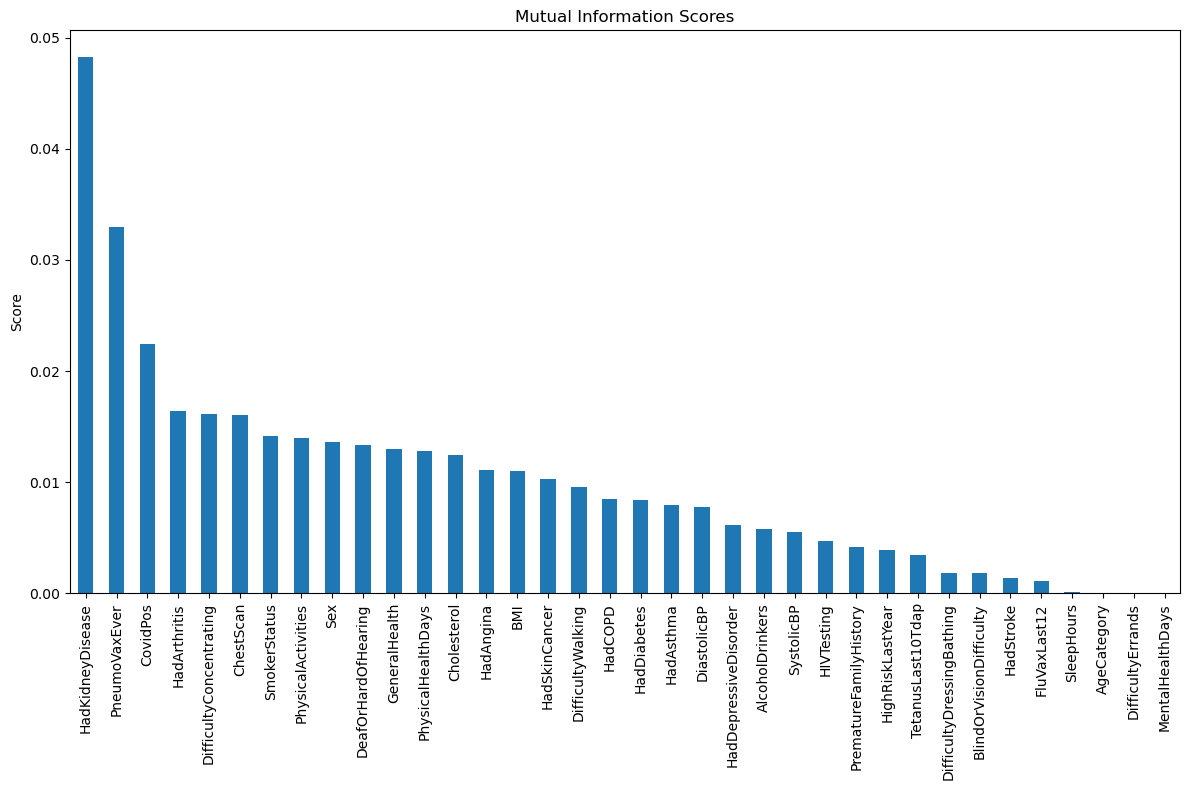

In [8]:
# Full Feature Set (Mandatory + Optional)
model_features = [
    'Sex', 'GeneralHealth', 'PhysicalHealthDays', 'MentalHealthDays',
     'PhysicalActivities', 'SleepHours',
    'HadAngina', 'HadStroke', 'HadAsthma', 'HadSkinCancer', 'HadCOPD',
    'HadDepressiveDisorder', 'HadKidneyDisease', 'HadArthritis',
    'HadDiabetes', 'DeafOrHardOfHearing', 'BlindOrVisionDifficulty',
    'DifficultyConcentrating', 'DifficultyWalking', 'DifficultyDressingBathing',
    'DifficultyErrands', 'SmokerStatus', 'ChestScan', 'AgeCategory', 'BMI',
    'AlcoholDrinkers', 'HIVTesting', 'FluVaxLast12', 'PneumoVaxEver',
    'TetanusLast10Tdap', 'HighRiskLastYear', 'CovidPos', 'SystolicBP',
    'DiastolicBP', 'Cholesterol', 'PrematureFamilyHistory'
]

# Only Mandatory Features (subset)
mandatory_features = [
    'Sex', 'AgeCategory', 'SystolicBP', 'DiastolicBP', 'Cholesterol',
    'BMI', 'SmokerStatus', 'AlcoholDrinkers', 'HadDiabetes',
    'HadAngina', 'HadStroke', 'PhysicalActivities', 'PrematureFamilyHistory'
]
# Identify optional features
optional_features = list(set(model_features) - set(mandatory_features))
import pandas as pd
import numpy as np
from sklearn.feature_selection import mutual_info_classif
from sklearn.preprocessing import LabelEncoder

# Assume 'df' is your DataFrame and 'target' is your target variable
# Ensure all features are present in the DataFrame
model_features = mandatory_features + optional_features
df = df[model_features + ['HadHeartAttack']].dropna()

# Encode categorical variables
df_encoded = df.copy()
for col in df_encoded.select_dtypes(include=['object', 'category']).columns:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col])

# Separate features and target
X = df_encoded[model_features]
y = df_encoded['HadHeartAttack']

# Determine which features are discrete
discrete_features = X.dtypes == int

# Compute mutual information
mi_scores = mutual_info_classif(X, y, discrete_features=discrete_features)
mi_series = pd.Series(mi_scores, index=model_features).sort_values(ascending=False)
import matplotlib.pyplot as plt

# Plot mutual information scores
plt.figure(figsize=(12, 8))
mi_series.plot(kind='bar')
plt.title('Mutual Information Scores')
plt.ylabel('Score')
plt.tight_layout()
plt.savefig('mutual_information_scores.png')
plt.show()



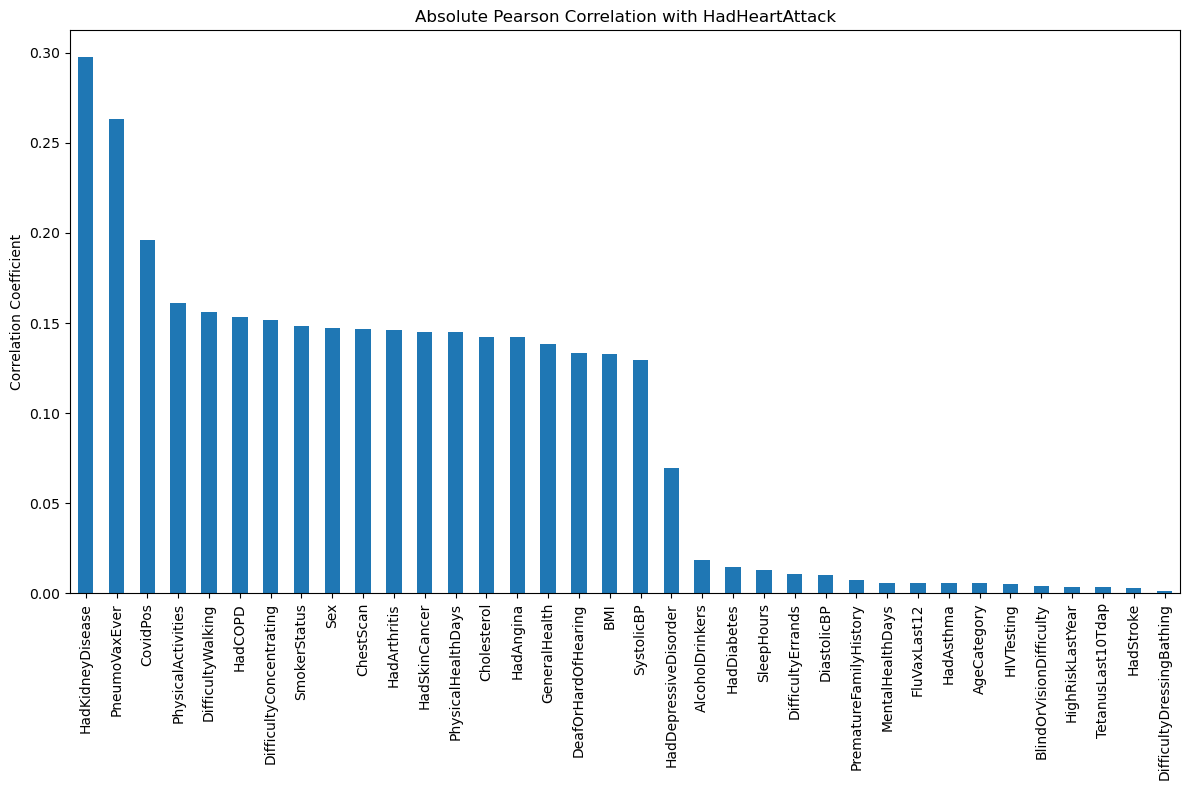

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder

# Define your feature sets
model_features = [
    'Sex', 'GeneralHealth', 'PhysicalHealthDays', 'MentalHealthDays',
    'PhysicalActivities', 'SleepHours', 'HadAngina', 'HadStroke',
    'HadAsthma', 'HadSkinCancer', 'HadCOPD', 'HadDepressiveDisorder',
    'HadKidneyDisease', 'HadArthritis', 'HadDiabetes', 'DeafOrHardOfHearing',
    'BlindOrVisionDifficulty', 'DifficultyConcentrating', 'DifficultyWalking',
    'DifficultyDressingBathing', 'DifficultyErrands', 'SmokerStatus',
    'ChestScan', 'AgeCategory', 'BMI', 'AlcoholDrinkers', 'HIVTesting',
    'FluVaxLast12', 'PneumoVaxEver', 'TetanusLast10Tdap', 'HighRiskLastYear',
    'CovidPos', 'SystolicBP', 'DiastolicBP', 'Cholesterol',
    'PrematureFamilyHistory'
]

mandatory_features = [
    'Sex', 'AgeCategory', 'SystolicBP', 'DiastolicBP', 'Cholesterol',
    'BMI', 'SmokerStatus', 'AlcoholDrinkers', 'HadDiabetes',
    'HadAngina', 'HadStroke', 'PhysicalActivities',
    'PrematureFamilyHistory'
]

# Identify optional features
optional_features = list(set(model_features) - set(mandatory_features))

# Combine all features
all_features = mandatory_features + optional_features

# Assume 'df' is your DataFrame and 'HadHeartAttack' is your target variable
# Ensure all features are present in the DataFrame
df = df[all_features + ['HadHeartAttack']].dropna()

# Encode categorical variables
df_encoded = df.copy()
for col in df_encoded.select_dtypes(include=['object', 'category']).columns:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col])

# Compute Pearson correlation coefficients
correlations = df_encoded.corr()['HadHeartAttack'].drop('HadHeartAttack')
abs_correlations = correlations.abs().sort_values(ascending=False)

# Plot the correlations
plt.figure(figsize=(12, 8))
abs_correlations.plot(kind='bar')
plt.title('Absolute Pearson Correlation with HadHeartAttack')
plt.ylabel('Correlation Coefficient')
plt.tight_layout()
plt.savefig('pearson_correlation_scores.png')
plt.show()


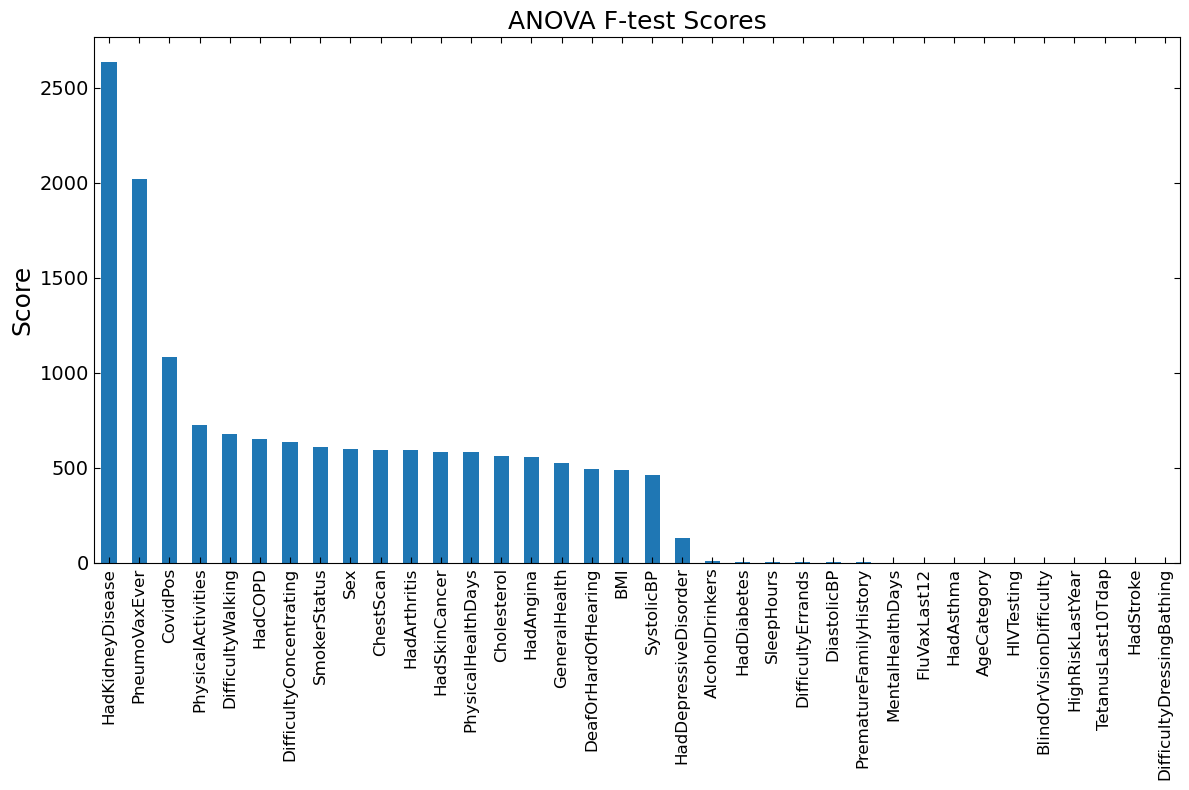

In [10]:
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.preprocessing import LabelEncoder
import pandas as pd
import matplotlib.pyplot as plt

# Assume df is your DataFrame and 'HadHeartAttack' is your target variable

# Encode categorical variables
df_encoded = df.copy()
for col in df_encoded.select_dtypes(include=['object', 'category']).columns:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col])

X = df_encoded[model_features]
y = df_encoded['HadHeartAttack']

# Apply ANOVA F-test
anova_selector = SelectKBest(score_func=f_classif, k='all')
anova_selector.fit(X, y)
anova_scores = pd.Series(anova_selector.scores_, index=model_features).sort_values(ascending=False)

# Plot the scores
plt.figure(figsize=(12, 8))
anova_scores.plot(kind='bar')
# plt.tick_params(axis='both', which='both', direction='in', size=4, labelsize=14)
plt.tick_params(axis='x', which='both', bottom=True, top=True,direction='in', size=4, labelsize=12)
plt.tick_params(axis='y', which='both', left=True, right=True,direction='in', size=4, labelsize=14)
plt.title('ANOVA F-test Scores',fontsize=18)
plt.ylabel('Score',fontsize=18)
plt.tight_layout()
plt.savefig('anova_scores.png')
plt.show()



Training FNN...
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step

Training CNN...
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

Training LSTM...
128/128 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step

Training CNN_LSTM...
128/128 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step

Training Wide_Deep...
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

Training Residual...
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

Training Attention...
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

Training FNN...
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  

Training CNN...
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

Training LSTM...
128/128 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step

Training CNN_LSTM...
128/128 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step

Training Wide_Deep...
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step

Training Residual...
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step

Training Attention...
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


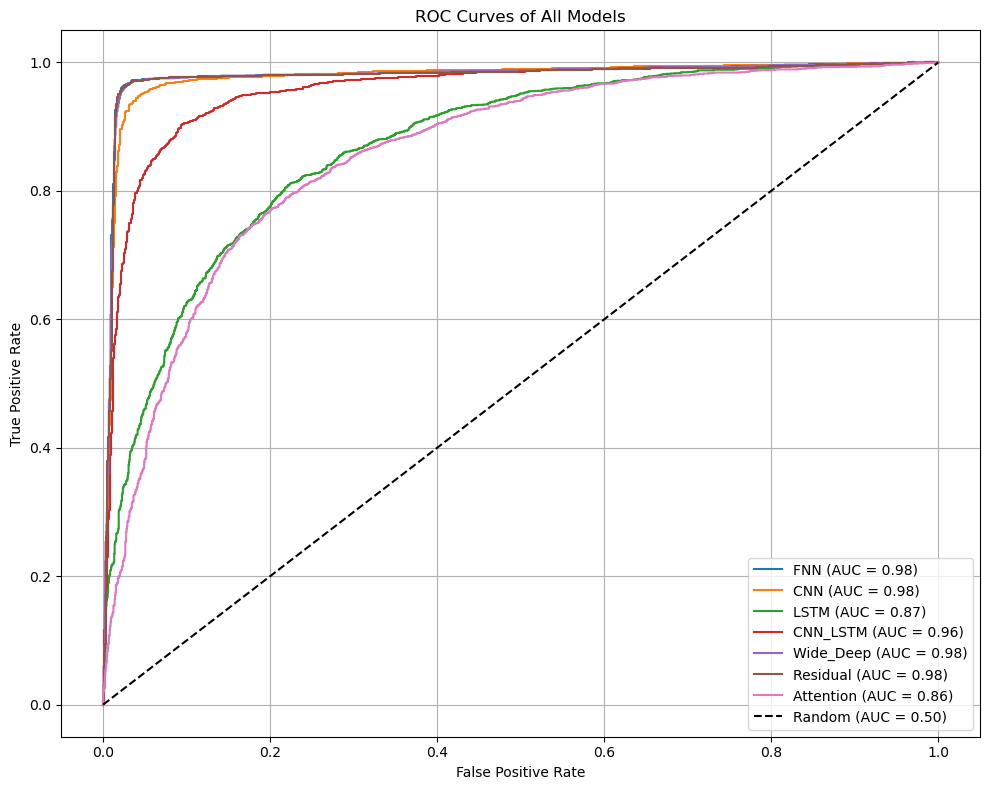


Performance table saved as 'performance_table.csv'
           Accuracy  Precision  Recall  F1 Score  ROC AUC
Model                                                    
FNN            0.97       0.97    0.97      0.97     0.98
CNN            0.95       0.96    0.94      0.95     0.98
LSTM           0.79       0.79    0.80      0.79     0.87
CNN_LSTM       0.90       0.92    0.88      0.90     0.96
Wide_Deep      0.97       0.97    0.96      0.97     0.98
Residual       0.97       0.97    0.96      0.97     0.98
Attention      0.78       0.78    0.79      0.79     0.86


In [11]:
# Step 1: Data Preprocessing
X = df.drop(columns=['HadHeartAttack'])  # Features
y = df['HadHeartAttack']  # Target variable

# --- 1. Split data into train (70%), validation (15%), and test (15%) ---
X_train_val, X_test, y_train_val, y_test = train_test_split(X, y, test_size=0.15, random_state=42, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=0.1765, random_state=42, stratify=y_train_val)
# (0.1765 * 0.85 ≈ 0.15)

# --- 2. Normalize and reshape ---
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

X_train_3d = X_train_scaled.reshape((X_train_scaled.shape[0], X_train_scaled.shape[1], 1))
X_val_3d = X_val_scaled.reshape((X_val_scaled.shape[0], X_val_scaled.shape[1], 1))
X_test_3d = X_test_scaled.reshape((X_test_scaled.shape[0], X_test_scaled.shape[1], 1))

# --- 3. Fix dtype errors ---
X_train_scaled = X_train_scaled.astype(np.float32)
X_val_scaled = X_val_scaled.astype(np.float32)
X_test_scaled = X_test_scaled.astype(np.float32)
X_train_3d = X_train_3d.astype(np.float32)
X_val_3d = X_val_3d.astype(np.float32)
X_test_3d = X_test_3d.astype(np.float32)
y_train = y_train.astype(np.float32)
y_val = y_val.astype(np.float32)
y_test = y_test.astype(np.float32)


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report, roc_curve

import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, Conv1D, MaxPooling1D, Flatten, Input, LSTM, Concatenate, Add, Attention

# --- 3. Define models ---
def build_fnn(input_dim):
    model = Sequential([
        Dense(32, activation='relu', input_shape=(input_dim,)),
        Dropout(0.1),
        Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

def build_cnn(input_shape):
    model = Sequential([
        Conv1D(32, 2, activation='relu', input_shape=input_shape),
        MaxPooling1D(),
        Flatten(),
        Dense(32, activation='relu'),
        Dropout(0.1),
        Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

def build_lstm(input_shape):
    model = Sequential([
        LSTM(32, input_shape=input_shape),
        Dropout(0.1),
        Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

def build_cnn_lstm(input_shape):
    model = Sequential([
        Conv1D(32, 2, activation='relu', input_shape=input_shape),
        MaxPooling1D(),
        LSTM(32),
        Dropout(0.1),
        Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

def build_wide_deep(input_dim):
    input_layer = Input(shape=(input_dim,))
    wide = Dense(32, activation='relu')(input_layer)
    deep = Dense(32, activation='relu')(input_layer)
    deep = Dropout(0.1)(deep)
    merged = Concatenate()([wide, deep])
    output = Dense(1, activation='sigmoid')(merged)
    model = Model(inputs=input_layer, outputs=output)
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

def build_residual(input_dim):
    input_layer = Input(shape=(input_dim,))
    x = Dense(64, activation='relu')(input_layer)
    x = Dropout(0.3)(x)
    skip = Dense(64, activation='relu')(input_layer)
    x = Add()([x, skip])
    x = Dense(1, activation='sigmoid')(x)
    model = Model(inputs=input_layer, outputs=x)
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

def build_attention(input_shape):
    input_layer = Input(shape=input_shape)
    query = Dense(64)(input_layer)
    value = Dense(64)(input_layer)
    attention_output = Attention()([query, value])
    x = Flatten()(attention_output)
    x = Dropout(0.3)(x)
    x = Dense(1, activation='sigmoid')(x)
    model = Model(inputs=input_layer, outputs=x)
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

# --- 4. Build model dictionary ---
models = {
    'FNN': build_fnn(X_train_scaled.shape[1]),
    'CNN': build_cnn((X_train_scaled.shape[1], 1)),
    'LSTM': build_lstm((X_train_scaled.shape[1], 1)),
    'CNN_LSTM': build_cnn_lstm((X_train_scaled.shape[1], 1)),
    'Wide_Deep': build_wide_deep(X_train_scaled.shape[1]),
    'Residual': build_residual(X_train_scaled.shape[1]),
    'Attention': build_attention((X_train_scaled.shape[1], 1))
}

# --- 5. Train and evaluate ---
results = {}
roc_data = {}
histories = {}

for name, model in models.items():
    print(f"\nTraining {name}...")
    if name in ['FNN', 'Wide_Deep', 'Residual']:
        history = model.fit(X_train_scaled, y_train, epochs=10, batch_size=32, verbose=0,
                            validation_data=(X_val_scaled, y_val))
        y_pred_prob = model.predict(X_test_scaled).flatten()
    else:
        history = model.fit(X_train_3d, y_train, epochs=10, batch_size=32, verbose=0,
                            validation_data=(X_val_3d, y_val))
        y_pred_prob = model.predict(X_test_3d).flatten()

    # Store history
    histories[name] = history

for name, model in models.items():
    print(f"\nTraining {name}...")
    if name in ['FNN', 'Wide_Deep', 'Residual']:
        model.fit(X_train_scaled, y_train, epochs=10, batch_size=32, verbose=0)
        y_pred_prob = model.predict(X_test_scaled).flatten()
    else:
        model.fit(X_train_3d, y_train, epochs=10, batch_size=32, verbose=0)
        y_pred_prob = model.predict(X_test_3d).flatten()

    y_pred = (y_pred_prob > 0.5).astype(int)
    fpr, tpr, _ = roc_curve(y_test, y_pred_prob)

    results[name] = {
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred),
        'recall': recall_score(y_test, y_pred),
        'f1_score': f1_score(y_test, y_pred),
        'roc_auc': roc_auc_score(y_test, y_pred_prob),
        'classification_report': classification_report(y_test, y_pred)
    }
    roc_data[name] = (fpr, tpr)

# --- 6. Plot ROC curves ---
plt.figure(figsize=(10, 8))
for name, (fpr, tpr) in roc_data.items():
    auc = results[name]['roc_auc']
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc:.2f})")

plt.plot([0, 1], [0, 1], 'k--', label='Random (AUC = 0.50)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves of All Models')
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.savefig("roc_curve_all_models.png")
plt.show()

# --- 7. Create and save performance table ---
performance_df = pd.DataFrame({
    model_name: {
        "Accuracy": round(metrics['accuracy'], 2),
        "Precision": round(metrics['precision'], 2),
        "Recall": round(metrics['recall'], 2),
        "F1 Score": round(metrics['f1_score'], 2),
        "ROC AUC": round(metrics['roc_auc'], 2)
    }
    for model_name, metrics in results.items()
}).T

performance_df.index.name = 'Model'
performance_df.to_csv("performance_table.csv")
print("\nPerformance table saved as 'performance_table.csv'")
print(performance_df)


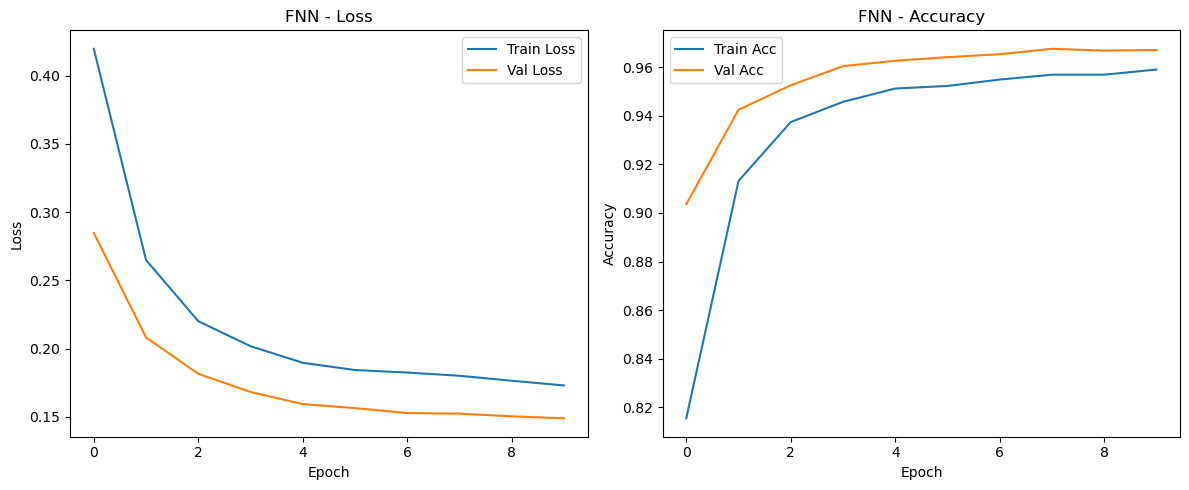

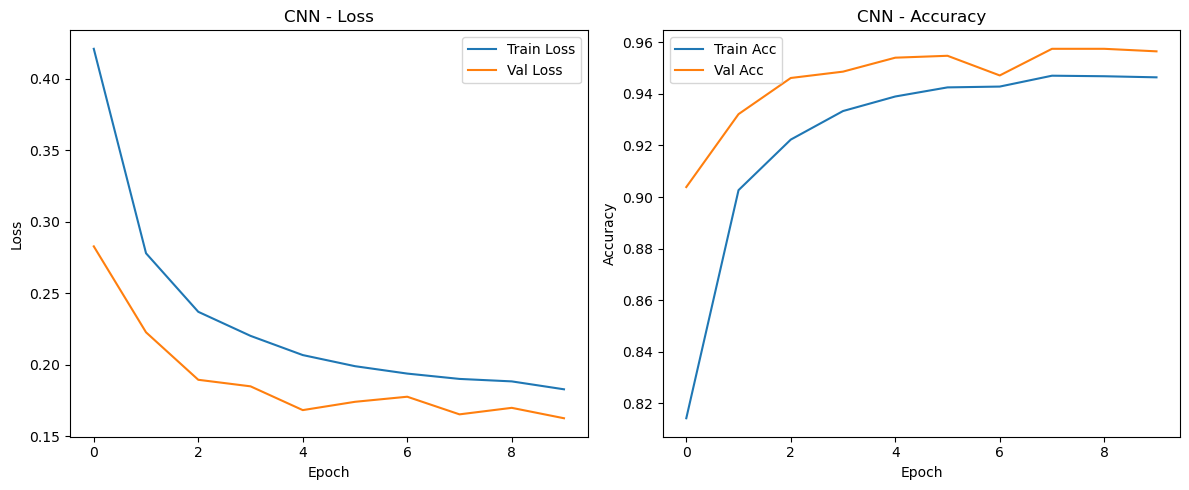

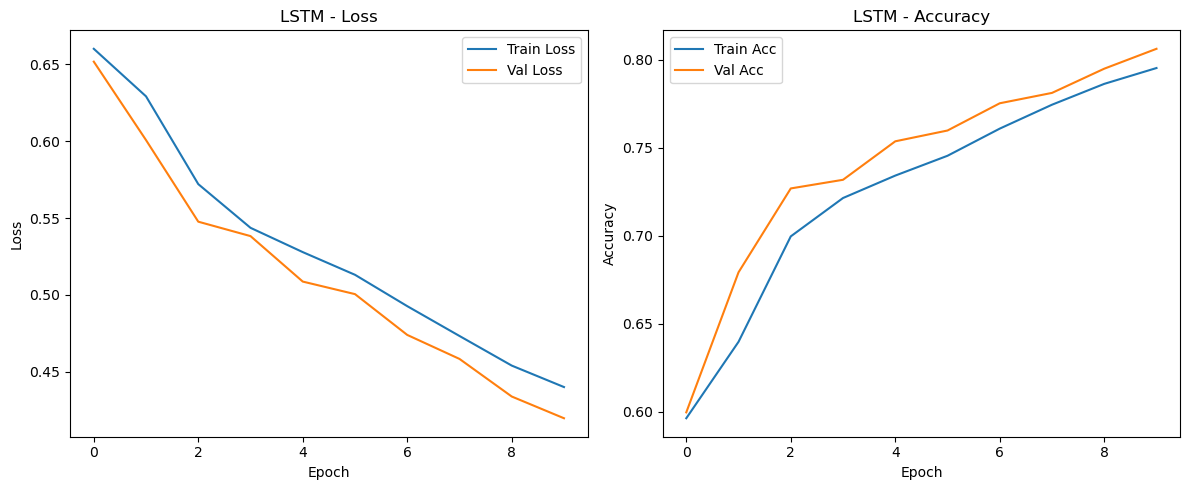

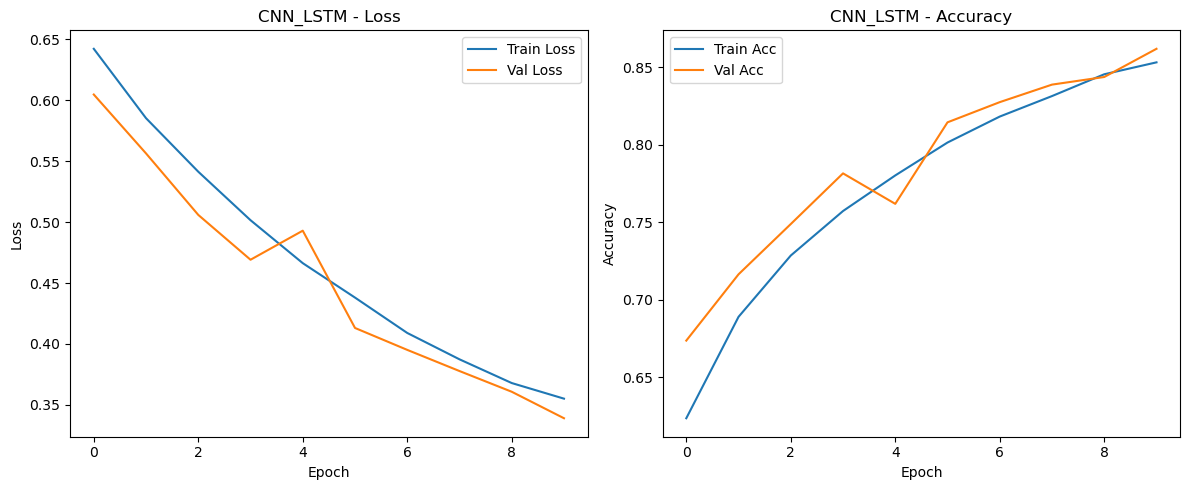

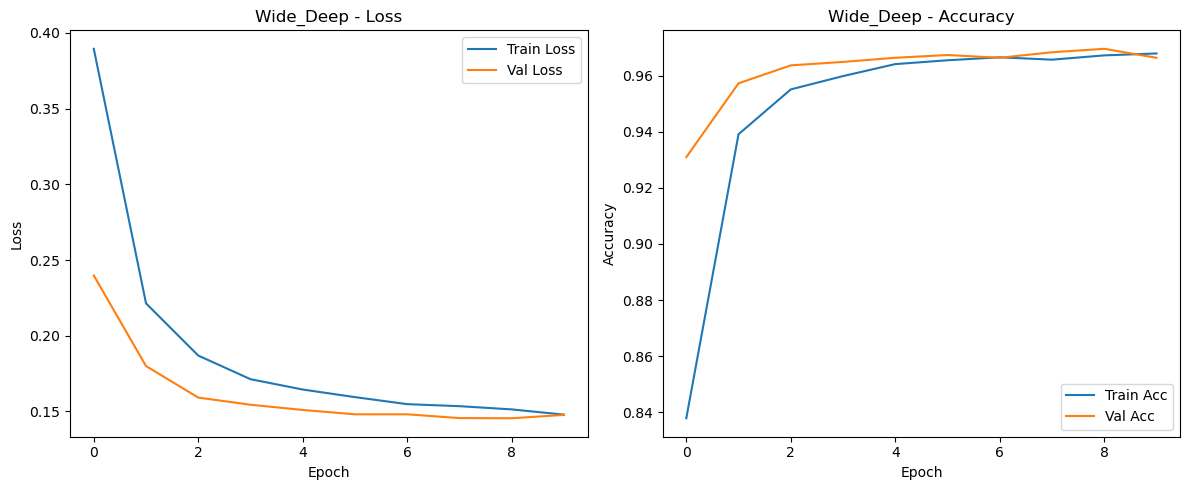

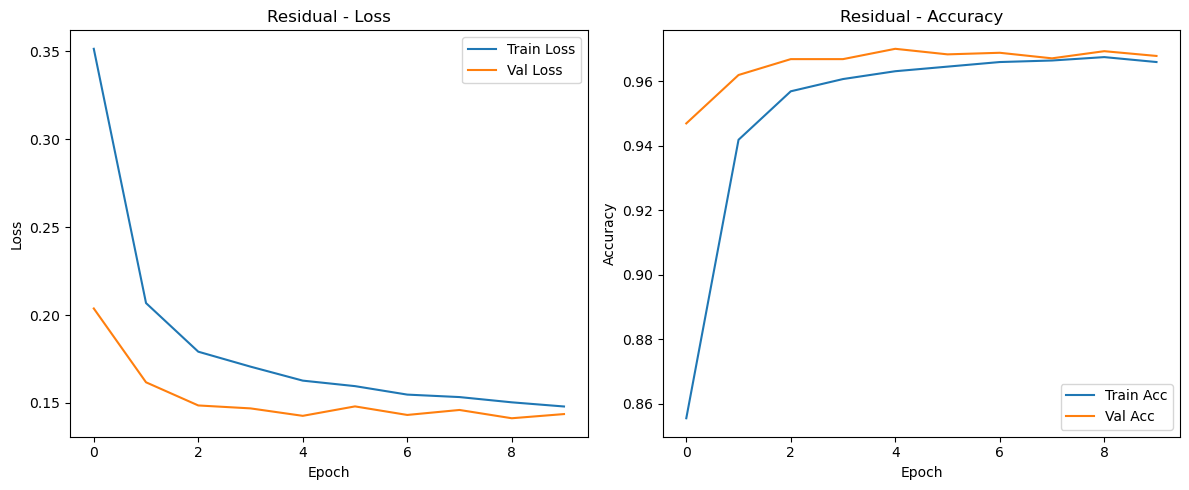

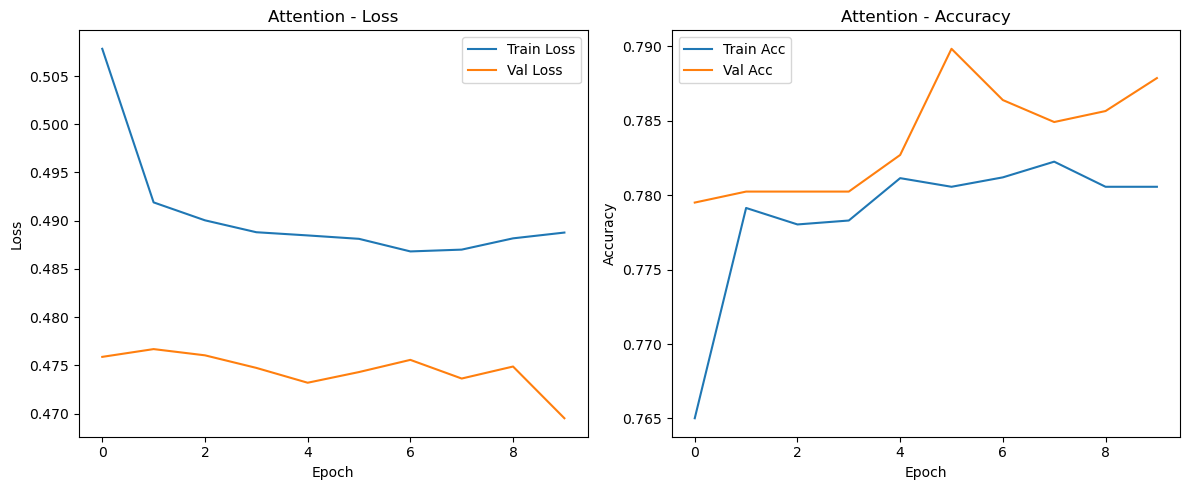

In [79]:
import matplotlib.pyplot as plt

for name, history in histories.items():
    plt.figure(figsize=(12, 5))

    # Loss plot
    plt.subplot(1, 2, 1)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Val Loss')
    plt.title(f'{name} - Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    # Accuracy plot
    plt.subplot(1, 2, 2)
    plt.plot(history.history['accuracy'], label='Train Acc')
    plt.plot(history.history['val_accuracy'], label='Val Acc')
    plt.title(f'{name} - Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.tight_layout()
    plt.savefig('loss_accuracy.png')
    plt.show()


In [80]:
import pickle

# --- Save Scaler ---
with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

# --- Save Label Encoders (if used) ---
label_encoders = {}
for col in df.select_dtypes(include=['object', 'category']).columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le

with open('label_encoders.pkl', 'wb') as f:
    pickle.dump(label_encoders, f)


In [81]:
best_model_name = max(results, key=lambda x: results[x]['roc_auc'])
best_model = models[best_model_name]

# Save best model
best_model.save('heart_attack_model.h5')
print(f"✅ Best model '{best_model_name}' saved as 'heart_attack_model.h5'")


✅ Best model 'FNN' saved as 'heart_attack_model.h5'
